# Analise de Dados: Preço de Aluguel em SP

## Carregamento dos Dados

Os dados foram carregados diretamente de um arquivo CSV que se encontra no Google Driver

In [ ]:
# Importar bibliotecas necessárias
import shap
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV

In [ ]:
#Carregando os dados
base = pd.read_csv('/content/drive/MyDrive/Regressao_Linear/sao-paulo-properties-april-2019.csv')

#Guardando as informações sobre residencias que estejam somente para locação
dados = base[base['Negotiation Type'] == 'rent']

#Criando uma nova coluna somente com as regiões
dados[['District', 'City']] = dados['District'].str.split('/', expand=True)

#Deletando as colunas que não irao fazer parte da analise e modelo
dados = dados.drop(['New','City', 'Property Type', 'Negotiation Type', 'Latitude','Longitude'], axis=1)


In [ ]:
#Verificar valores ausentes
print(dados.isnull().sum())

#Verificar as primeiras linhas dos dados
dados.head()

Price            0
Condo            0
Size             0
Rooms            0
Toilets          0
Suites           0
Parking          0
Elevator         0
Furnished        0
Swimming Pool    0
District         0
dtype: int64


,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,District
0,930,220,47,2,2,1,1,0,0,0,Artur Alvim
1,1000,148,45,2,2,1,1,0,0,0,Artur Alvim
2,1000,100,48,2,2,1,1,0,0,0,Artur Alvim
3,1000,200,48,2,2,1,1,0,0,0,Artur Alvim
4,1300,410,55,2,2,1,1,1,0,0,Artur Alvim


## Descrição dos Dados




Os dados incluem as seguintes variáveis



* **Price**: Preço final anunciado (R$ Real Brasileiro)
* **Condo**: Despesas de condominio
* **Size**: O tamanho da propriedade em metros quadrados m² (somente áreas privadas)
* **Rooms**: Numero de quartos
* **Toilets**: Número de banheiros (todos os banheiros)
* **Suites**: Número de quartos com casa de banho privativa
* **Parking**: Número de vagas de estacionamento
* **Elevator**: Elevador no prédio (1 = Sim, 0 = Não)
* **Furnished**: Propriedade imobiliada/financiada (1 = Sim, 0 = Não)
* **Swimming Pool**: Imovél com piscina (1 = Sim, 0 = Não)

## Estatisticas Descritivas

Vamos agora verificar algumas estatísticas descritivas dos dados

In [ ]:
#Estatisticas gerais do conjunto de dados
dados.describe()

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool
count,7228.000000,7228.000000,7228.000000,7228.000000,7228.000000,7228.000000,7228.000000,7228.000000,7228.000000,7228.000000
mean,3077.669065,825.194798,89.486165,2.304234,2.105562,1.024488,1.452269,0.299806,0.172939,0.487963
std,3522.830284,835.621937,63.976416,0.829108,0.998162,0.884241,0.889535,0.458205,0.378220,0.499890
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1350.000000,395.750000,52.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,2000.000000,595.000000,67.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,3300.000000,990.000000,100.000000,3.000000,2.000000,1.000000,2.000000,1.000000,0.000000,1.000000
max,50000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.000000,1.000000,1.000000,1.000000


## Análise de Distribuicoes

A seguir, graficos das ditribuições dos atributos numericos e categóricos

In [ ]:
#Variáveis numéricas
var_num = ['Price','Condo','Size','Rooms','Toilets','Suites','Parking']

#Variaveis Categoricas
var_cat = ['Elevator','Furnished','Swimming Pool']

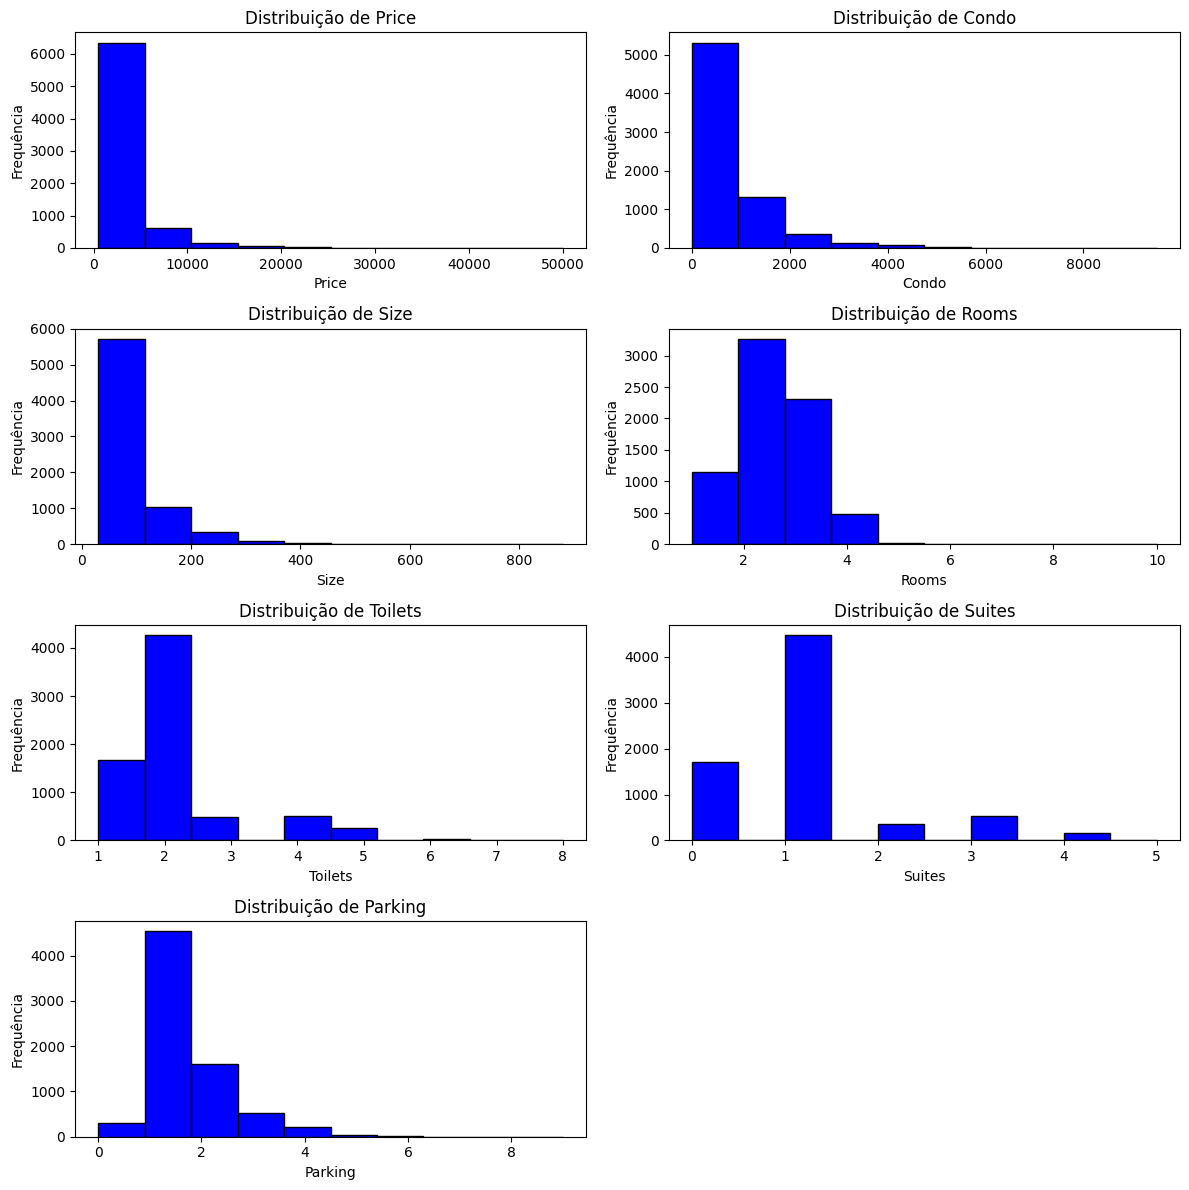

In [ ]:
#Plotar distribuicoes numericas

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 12))

for i, col in enumerate(var_num):
    ax = axes[i//2, i%2]
    ax.hist(dados[col], bins=10, color='blue',edgecolor='black')
    ax.set_title(f'Distribuição de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')

fig.delaxes(axes[3,1])
plt.tight_layout()
plt.show()

In [ ]:
#A variavel alvo 'Price', visualizando pelo os graficos, esta com a distribuição assimetrica. Devido a isso vamos criar uma nova variavel com logatimo, para melhor trabalhar no modelo preditivo
dados['log_Price'] = np.log(dados['Price'])

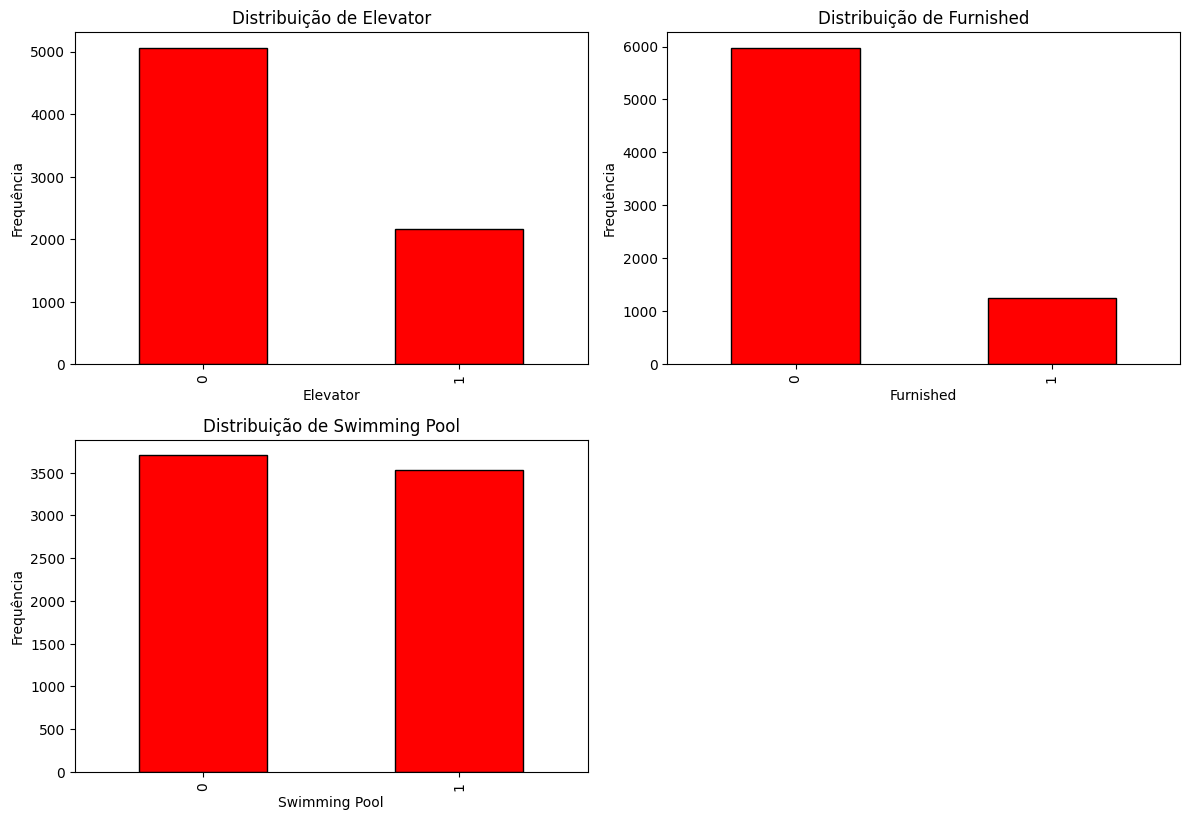

In [ ]:
#Plotar distribuicoes numericas

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))

for i, col in enumerate(var_cat):
    ax = axes[i//2,i%2]
    dados[col].value_counts().plot(kind='bar', ax=ax, color='red', edgecolor='black')
    ax.set_title(f'Distribuição de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')

fig.delaxes(axes[1,1])
fig.delaxes(axes[2,0])
fig.delaxes(axes[2,1])
plt.tight_layout()
plt.show()

## Análise Exploratoria

**Mostrando a quantidade de residencias por bairro/distrito**

In [ ]:
#Calculando quantidade de distritos
frequencia_bairros = dados['District'].value_counts()

#Criando uma datafram com a frequencia dos bairros
tabela_qtd_bairros = pd.DataFrame({
    'Bairro': frequencia_bairros.index,
    'Quantidade': frequencia_bairros.values})

#Exibindo a dataframe
tabela_qtd_bairros.set_index('Bairro', inplace=True)
tabela_qtd_bairros

,Quantidade
Bairro,
Mooca,178
Moema,163
Vila Mariana,161
Morumbi,159
Pinheiros,153
...,...
Lajeado,8
Guaianazes,6
Parque do Carmo,6


**Média de valores de preço de aluguel por bairro**

In [ ]:
#Calculando a media de alguel por bairro
media_bairro = dados.groupby(['District']).agg({'Price': 'mean'}).reset_index().sort_values('Price', ascending=False)

#Criando um dataframe com a media de preço de aluguel por bairro
tabela_media_bairro = pd.DataFrame({
    'Bairro': media_bairro['District'],
    'Media_Preco': media_bairro['Price'].round(2)})

#Exibindo a dataframe
tabela_media_bairro.set_index('Bairro', inplace=True)
tabela_media_bairro

,Media_Preco
Bairro,
Itaim Bibi,8460.68
Iguatemi,8301.69
Alto de Pinheiros,7825.77
Moema,7547.99
Jardim Paulista,7409.91
...,...
Guaianazes,970.83
José Bonifácio,944.98
Lajeado,931.25


**Plotando um grafico mostrando os indices dos bairros com valores de alguel mais altos e mais baixos**

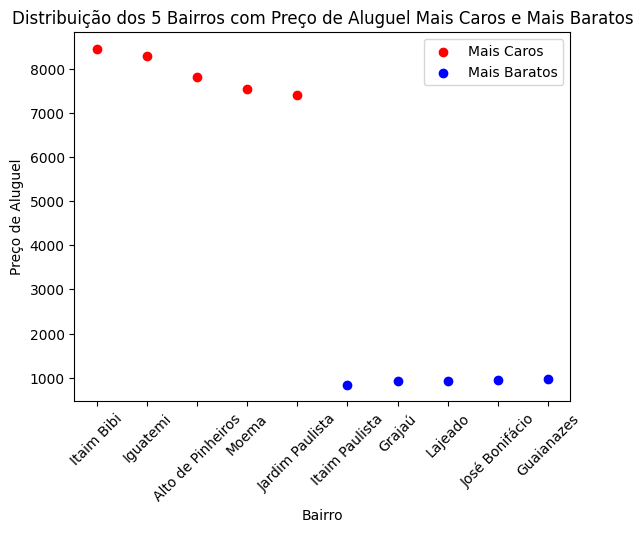

In [ ]:
#Duas variaveis, cada uma guarda os bairros com o valores mais altos e mais baixos

bairros_mais_caros = tabela_media_bairro.nlargest(5, 'Media_Preco')
bairros_mais_baratos = tabela_media_bairro.nsmallest(5, 'Media_Preco')

plt.scatter(bairros_mais_caros.index, bairros_mais_caros['Media_Preco'], color='red', label='Mais Caros')

plt.scatter(bairros_mais_baratos.index, bairros_mais_baratos['Media_Preco'], color='blue', label='Mais Baratos')

#Exibindo o grafico
plt.title('Distribuição dos 5 Bairros com Preço de Aluguel Mais Caros e Mais Baratos')
plt.xlabel('Bairro')
plt.xticks(rotation=45)
plt.ylabel('Preço de Aluguel')
plt.legend()
plt.show()



**Correlação entre características dos Imóveis e Preço de Aluguel**

,log_Price,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool
log_Price,1.000000,0.851495,0.695093,0.722084,0.446273,0.622160,0.615725,0.670905,0.062063,0.244131,0.333407
Price,0.851495,1.000000,0.700361,0.731795,0.390951,0.583488,0.588329,0.640743,0.031860,0.171859,0.206884
Condo,0.695093,0.700361,1.000000,0.812374,0.494153,0.596520,0.597069,0.703888,0.020271,0.075928,0.198613
Size,0.722084,0.731795,0.812374,1.000000,0.673232,0.694294,0.701954,0.752954,0.006993,0.005886,0.148408
Rooms,0.446273,0.390951,0.494153,0.673232,1.000000,0.557247,0.545859,0.592387,0.000993,-0.104705,0.151225
Toilets,0.622160,0.583488,0.596520,0.694294,0.557247,1.000000,0.920932,0.703447,0.143176,0.068190,0.262526
Suites,0.615725,0.588329,0.597069,0.701954,0.545859,0.920932,1.000000,0.718788,0.106189,0.068014,0.267219
Parking,0.670905,0.640743,0.703888,0.752954,0.592387,0.703447,0.718788,1.000000,0.027476,0.066077,0.304904
Elevator,0.062063,0.031860,0.020271,0.006993,0.000993,0.143176,0.106189,0.027476,1.000000,0.095207,0.150773
Furnished,0.244131,0.171859,0.075928,0.005886,-0.104705,0.068190,0.068014,0.066077,0.095207,1.000000,0.185192


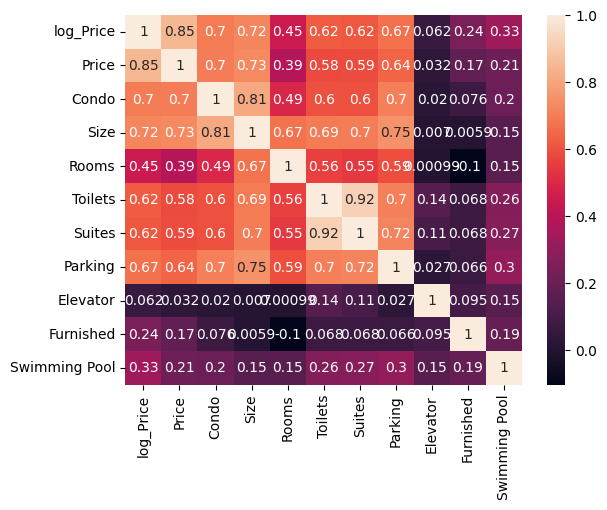

In [ ]:
#Selecionando as variaveis para analisar na correlação
dados_cor = dados[['log_Price','Price','Condo','Size','Rooms','Toilets','Suites','Parking','Elevator','Furnished','Swimming Pool']]

#Criando a correlação entre as variaveis
correlacao = dados_cor.corr()

#Visualizando a correlação e o grafico
sns.heatmap(correlacao, annot=True)
correlacao

## Preparação dos Dados para Modelagem

In [ ]:
#Separar variáveis preditoras (x) e alvo (y)
x = dados[['Condo','Size','Rooms','Toilets','Suites','Parking','Elevator','Furnished','Swimming Pool']]
y = dados['log_Price']

In [ ]:
#Dividir os dados em treino e teste (80% treino, 20% teste)
x_treino_1, x_teste_1, y_treino_1,y_teste_1 = train_test_split(x,y, test_size=0.2, random_state=42)

## Treinamento de Modelos Preditivos



---


**Primeiro modelo**

> Random Forest Regressor



In [ ]:
#Treinar o modelo de Regressão Linear usando Random Forest Regressor
modelo_1 = RandomForestRegressor()
modelo_1.fit(x_treino_1, y_treino_1)

RandomForestRegressor()

In [ ]:
#Capturando as variaveis mais "importantes" que foram usadas na criação da arvore de decisão
importancia = modelo_1.feature_importances_
variaveis = list(zip(['Condo','Size','Rooms','Toilets','Suites','Parking','Elevator','Furnished','Swimming Pool'], importancia))
variaveis_ordenadas = sorted(variaveis, key=lambda x: x[1], reverse=True)
for coluna, importancia in variaveis_ordenadas:
    print(f"{coluna}: {importancia.round(3)}")

Size: 0.62
Condo: 0.203
Swimming Pool: 0.035
Furnished: 0.034
Rooms: 0.029
Suites: 0.027
Parking: 0.025
Toilets: 0.015
Elevator: 0.013


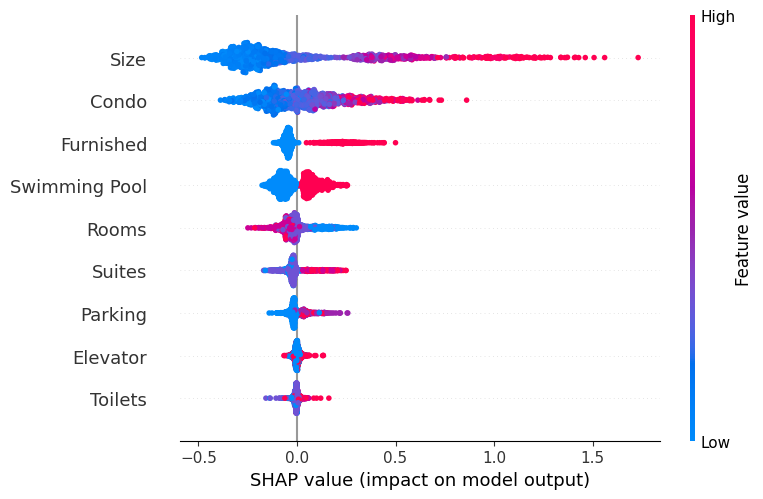

In [ ]:
#O SHAP esta sendo mostrado para verificar como cada atributo afeta para o resultado do modelo
expln = shap.TreeExplainer(modelo_1)
shap_values = expln.shap_values(x_teste_1)
shap.summary_plot(shap_values, x_teste_1)

In [ ]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

#Método (RFE) para selecionar as melhores features (variaves independentes/atributos)
rfg = RandomForestRegressor(random_state=42)
parametros = {'n_features_to_select': range(1, x.shape[1] + 1)}
rfe = RFE(rfg)

#Treinamento do modelo k vezes, testando todas as combinações possiveis de valores, calculando a performance média do modelo em cada combinação
grid = GridSearchCV(rfe, parametros, cv=kf, scoring='r2')
grid.fit(x, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RFE(estimator=RandomForestRegressor(random_state=42)),
             param_grid={'n_features_to_select': range(1, 10)}, scoring='r2')

In [ ]:
#Mostrando em tela a quantidade certa de variaveis para o nosso modelo
print("Melhor número de variáveis:", grid.best_params_['n_features_to_select'])

Melhor número de variáveis: 7


In [ ]:
#Visualizando as melhores variaveis para o nosso modelo.
for i,col in zip(range(x.shape[1]), x.columns):
  print(f"{col} selected={grid.best_estimator_.support_[i]} rank={grid.best_estimator_.ranking_[i]}") # Access support_ and ranking_ from grid.best_estimator_

Condo selected=True rank=1
Size selected=True rank=1
Rooms selected=True rank=1
Toilets selected=False rank=2
Suites selected=True rank=1
Parking selected=True rank=1
Elevator selected=False rank=3
Furnished selected=True rank=1
Swimming Pool selected=True rank=1


In [ ]:
#Obtendo o Coeficiente de Determinação do nosso primeiro modelo
print(f"R²: {modelo_1.score(x_treino_1, y_treino_1)}")

R²: 0.9554754525233865


**Devido ao coeficiente de determinação (R²) estar muito alto, é provável que o nosso primeiro modelo esteja enfrentando problemas de generalização, apresentando um ajuste excessivo aos dados de teste (overfitting). Para verificar a capacidade de generalização do modelo, utilizaremos a técnica de validação cruzada (KFold)**

In [ ]:
#Exibição de cada coeficiente do teste e a media
scores = cross_val_score(modelo_1, x, y, cv=kf, scoring='r2')
print(f"R² Score for each fold: {[round(score, 4) for score in scores]}")
print(f"Média R² total: {scores.mean()}")

R² Score for each fold: [0.7394, 0.7051, 0.7286, 0.7286, 0.7361]
Média R² total: 0.7275715439104268




---


**Segundo modelo**

> Random Forest Regressor



**O segundo modelo está sendo desenvolvido com base em toda a análise e nos testes realizados no primeiro modelo, utilizando as variáveis que mais influenciam a variável alvo.**

In [ ]:
x = dados[['Condo','Size','Rooms','Suites','Parking','Furnished','Swimming Pool']]

In [ ]:
x_treino_2, x_teste_2, y_treino_2,y_teste_2 = train_test_split(x,y, test_size=0.20, random_state=42)

In [ ]:
modelo_2 = RandomForestRegressor()
modelo_2.fit(x_treino_2, y_treino_2)

RandomForestRegressor()

In [ ]:
#Obtendo o Coeficiente de Determinação do nosso primeiro modelo
round(modelo_2.score(x_treino_2, y_treino_2),3)

0.952

**Devido ao coeficiente de determinação (R²) estar muito alto, é provável que o nosso segundo modelo esteja tambem enfrentando problemas de sobreajuste. E para verificar a capacidade de generalização do modelo, utilizaremos a técnica de validação cruzada (KFold)**

In [ ]:
#Exibição de cada coeficiente do teste e a media
scores_2 = cross_val_score(modelo_2, x, y, cv=kf, scoring='r2')
print(f"R² Score for each fold: {[round(score, 4) for score in scores_2]}")
print(f"Média R² total: {scores_2.mean()}")

R² Score for each fold: [0.7432, 0.7044, 0.7339, 0.7286, 0.729]
Média R² total: 0.7278148599258624


## Teste de predição e visualização de desempenho dos modelos

In [ ]:
#Capturando a performance de teste de cada modelo, predição.
pred_modelo_1 = modelo_1.predict(x_teste_1)
pred_modelo_2 = modelo_2.predict(x_teste_2)

#Visualizando os erros de previsão de cada modelo
print('Primeiro modelo')
print(f"MAE: {mean_absolute_error(y_teste_1, pred_modelo_1)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_teste_1, pred_modelo_1))}")
print('-------------------------')
print('Segundo modelo')
print(f"MAE: {mean_absolute_error(y_teste_2, pred_modelo_2)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_teste_2, pred_modelo_2))}")



Primeiro modelo
MAE: 0.26722396125389053
RMSE: 0.3679074067704404
-------------------------
Segundo modelo
MAE: 0.2651608888496027
RMSE: 0.36647844720365486


**Abaixo um comparativo entre a previsão de cada modelo com a variavel alvo real**

<Axes: title={'center': 'Primeiro Modelo - Previsto X Real'}, xlabel='Real', ylabel='Previsto'>

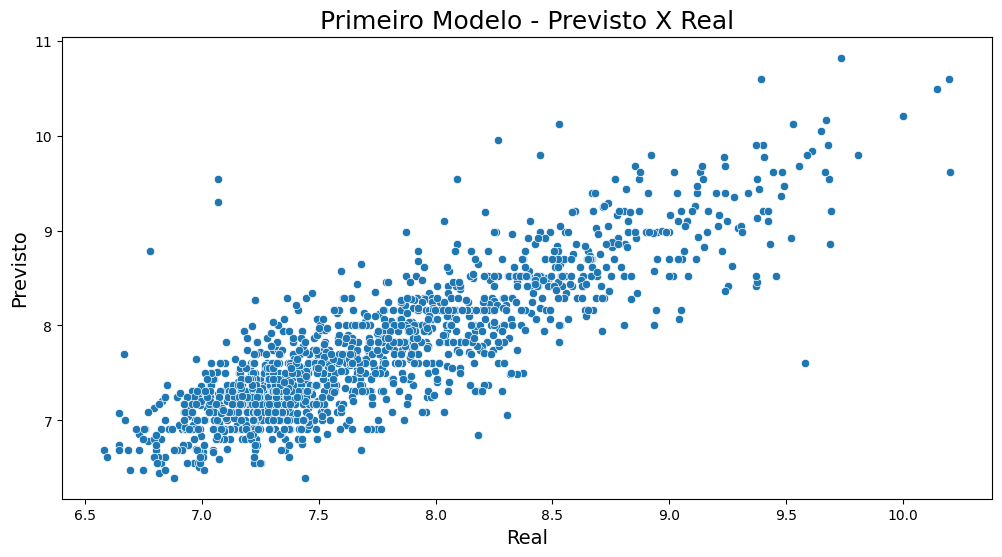

In [ ]:
#Plotando o comparativo entre o previsto e o resultado real do primeiro modelo
ax = sns.scatterplot(x = pred_modelo_1, y = y_teste_1)
ax.figure.set_size_inches(12, 6)
ax.set_title('Primeiro Modelo - Previsto X Real', fontsize=18)
ax.set_xlabel('Real', fontsize=14)
ax.set_ylabel('Previsto', fontsize=14)
ax

<Axes: title={'center': 'Segundo Modelo - Previsto X Real'}, xlabel='Real', ylabel='Previsto'>

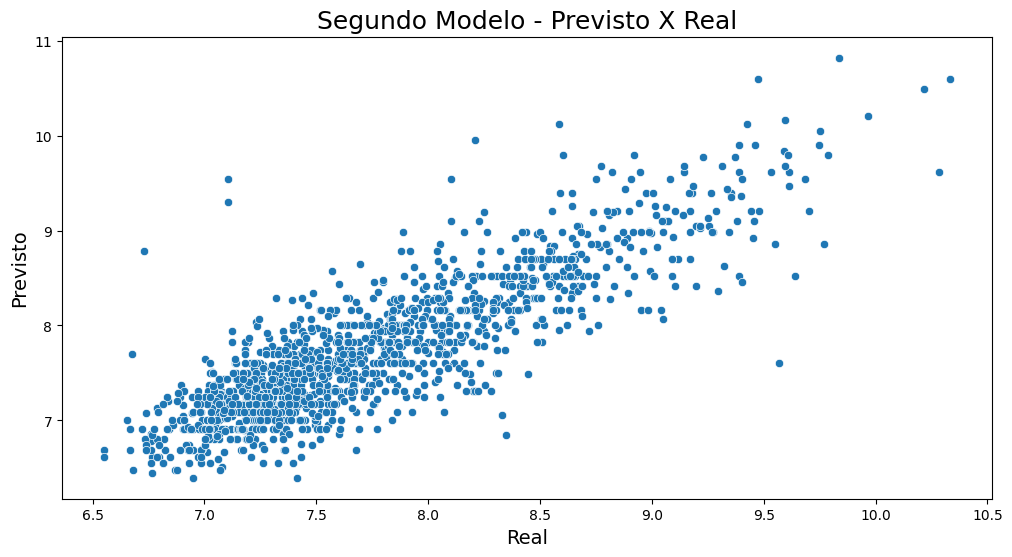

In [ ]:
#Plotando o comparativo entre o previsto e o resultado real do segundo modelo
ax = sns.scatterplot(x = pred_modelo_2, y = y_teste_2)
ax.figure.set_size_inches(12, 6)
ax.set_title('Segundo Modelo - Previsto X Real', fontsize=18)
ax.set_xlabel('Real', fontsize=14)
ax.set_ylabel('Previsto', fontsize=14)
ax

### Conclusão
Comparamos os dois modelos preditivos para estimar o preço do aluguel com base nas informações fornecidas. A partir da avaliação apresentada acima, podemos determinar qual modelo apresenta o melhor desempenho.

crédito: https://www.kaggle.com/datasets/argonalyst/sao-paulo-real-estate-sale-rent-april-2019